# **Coastal Water Temperature Seasonality and Trend Station Viewer**

Last updated on: 05/21/2026

## Overview
NOAA's CO-OPS collects trusted coastal data—including water levels, currents and water temperature—that helps keep navigation safe, supports commerce, and protects coastal communities and ecosystems. Since the early 1990s, over 220 water temperature sensors have been installed along U.S. coasts and in the Great Lakes. CO-OPS did an in-depth analysis on 174 stations with at least 20 years of data that is outlined in [Evaluation and quality control of CO-OPS coastal water temperature data](https://repository.library.noaa.gov/view/noaa/70917).

This notebook goes alongside the scientific analysis of this data published in [Frontiers of Marine Science] (https://doi.org/10.3389/fmars.2026.1863230) article with the primary objectives of demonstrating the applicability and usefulness of measuring coastal water temperature at NOAA water level monitoring stations in climate time scale studies, identifying the relationships between water temperature and sea level measured at the same stations, to compare water temperature at tide gauges against a well-known NOAA dataset used for water temperature: NOAA NESDIS OISST, and capture the local and regional patterns and variability and linear trends of water temperature along the US coasts.

## Prerequisites and running the Notebook
This notebook uses Python programming and users may run it either in **Google Colab** or **Jupyter Notebook**. To work offline, manage libraries and dependencies personally; using **Jupyter Notebook** is recommended. If you want cloud-based instant access, seamless co-operation and have access to good internet connection, **Google Colab** is the best option.

This notebook is designed so that people with limited familiarity with Python can run the notebook. To do so, go to the [github](https://github.com/NOAA-CO-OPS/coastal-water-temperature) [update link] page and click on the drop down menu under 'Code', then download the ZIP file. Extract the ZIP file and upload the Coastal_temp_seasonality_trend_viewer.ipynb within in the Seasonality and Trends Publication Folder into [google colab](https://colab.research.google.com/). [Explore different station/s](https://tidesandcurrents.noaa.gov) and change the station variable in step 3. There is also an option to run through all of the stations. The code creates two folders called Trends and Seasonal_cycles in your working directory for storing the created graphics and outputs a summary csv for the trend analysis. Lastly, click **Runtime** in the top menu and choose **Run All**. Then, when the 'Choose Files' box in step 2 becomes active, click on it and upload the MASTER_daily_clean_water_temp, MASTER_monthly_mean_water_temp, and the station_list_water_temp_climatepaper csvs. You will see a green check mark to the left of each cell as cells are successfully executed.

Users should be prepared to commit 30 minutes to familiarize themselves with the notebook, upload data, run code and examine results.

## Learning Outcomes
In this notebook users will be able to:
  1. Explore seasonality at 90 CO-OPS stations with high quality data
  2. Calculate linear trends based on the period of record as seen in the publication.

## Data Sources and Documentation

All data comes from CO-OPS's sensors. Stations with water temperature data can be found via [CO-OPS Metadata API](https://api.tidesandcurrents.noaa.gov/mdapi/prod/webapi/stations.json?type=watertemp). 6-min water temperature data can be accessed through [CO-OPS Data API](https://api.tidesandcurrents.noaa.gov/api/prod/).

The data, metadata, and results from the project are all available in a zip file: `Metadata and Results`.

The QA/QC’d daily averaged water temperature data used in the publication is available in the zip folder under MASTER_daily_clean_water_temp.csv where each column represents a station and each row is a date.

The QA/QC'd monthly averaged data is also available called MASTER_monthly_mean_water_temp.csv where each column represents a station and each row a month.

The `Station list and inventory.xlsx` contains basic station info including coordinates, region, POR, and metadata for both the WT and AT data.

The `Research output results.xlsx` contains 3 data tabs and 3 metadata tabs. 
  - `Seasonality` tab contains water temperature, air temperature, and mean sea level seasonality data including ranges, climatological peaks, and correlations/shifts between them.
  - `Trends` tab contains the water temperature trends (monthly, annual max, and annual min) as well as msl trends for each station.
  - `Daily distribution and extremes` tab contains mean observed values, variance, kurtosis, extreme percentiles of daily mean water temperature and daily mean water temperature anomalies.

  ## Software
  This tutorial uses the following Python packages
  - pandas
  - matplotlib
  - datetime
  - os
  - zipfile
  - numpy
  - warning
  - tabulate


## **Step 1**
## Install and Load Packages
Lets check if you have these packages installed. If not, this cell will install them.

In [1]:
# @title
import subprocess, sys
packages = ["pandas","matplotlib","datetime","numpy","statsmodels","tabulate","zipfile","tabulate","os"]
for package in packages:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import os
import zipfile
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.seasonal import STL
from tabulate import tabulate
from datetime import timedelta
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")
warnings.simplefilter('ignore', ConvergenceWarning)

## **Step 2**
## Upload Data
Here we will upload the MASTER_daily_clean_water_temp.csv, MASTER_monthly_mean_water_temp.csv, and station_list_water_temp_climatepaper.csv. These files can be found on the CO-OPS [Github](https://github.com/NOAA-CO-OPS) page in the [enter name of repository] with this notebook. If running on Google Colab, you can upload the files below. If running locally, the code will pull the data from your local repository.

In [3]:
#@title Upload the three required CSVs if using google colab

#this can take a few minuates to load
try:
    from google.colab import files
    #test if
    file_path = '/content/Metadata and Results.zip'
    if os.path.exists(file_path):
        print('Data already loaded in colab')
    else:
        uploaded = files.upload()
except ModuleNotFoundError:
    print("User running script locally")

User running script locally


In [5]:
# Unzip the uploaded file
zip_file = "Metadata and Results.zip"
extract_to = os.getcwd()  # Extract to current working directory

# Create target directory if it doesn't exist
os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"Files unzipped to {extract_to}")

Files unzipped to c:\Users\bailey.armos\projects\Temp_project\report_notebooks\dev_coastal-water-temperature\Seasonality and Trends Publication


In [7]:
stationsClim = pd.read_excel('Metadata and Results/Station list and inventory.xlsx', sheet_name='Data')
stationsClim['deploy_dt'] = pd.to_datetime(stationsClim['deploy_date'])
stationsClim['end_dt'] = pd.to_datetime(stationsClim['end_date'])

# Safety check: print the first few rows to make sure it loaded
print(f"Loaded {len(stationsClim)} stations from the list.")

Loaded 90 stations from the list.


In [8]:
print('Stations in the analysis are listed below.')
print(stationsClim['station_id'].unique())

Stations in the analysis are listed below.
[8410140 8413320 8418150 8449130 8447930 8452944 8454049 8452660 8461490
 8465705 8516945 8519483 8531680 8534720 8539094 8545240 8551910 8536110
 8557380 8573927 8574680 8573364 8594900 8577330 8635750 8632200 8637689
 8638863 8631044 8651370 8652587 8658120 8665530 8721604 8723970 8724580
 8725520 8726724 8728690 8729210 8729840 8762482 8761724 8768094 8770570
 8770971 8771341 8771450 8775870 8776604 9755371 9751401 9075099 9075014
 9063079 9063063 9063020 9459450 9455920 9455500 9454240 9455090 9453220
 9452210 9451600 9450460 9449880 9444090 9444900 9447130 9446484 9440910
 9435380 9432780 9431647 9419750 9418767 9416841 9415144 9414863 9414750
 9414290 9412110 9410660 9410230 1617433 1615680 1612480 1619910 1890000]


## **Step 3**
## Here we choose the station of interest or can run through and save plots for every station

In [9]:
# @title Run and output all station graphics or choose one station to plot below

station_choice = input('Option single or all: ')
if station_choice == 'single':
  station_selection = input('Input station ID: ')

## **Step 4**

- Read the csv files
- Calculate seasonal cycle
- Calculate linear trend rate
- Plot and save graphics and results

In [10]:
# @title Functions for calculating trends and plotting graphics

# Create directories if they don't exist
os.makedirs('Seasonal_cycles', exist_ok=True)
os.makedirs('Trends', exist_ok=True)
os.makedirs('Monthly_Climatology', exist_ok=True)
os.makedirs('Timeseries', exist_ok=True)

def monthly_climatology_plot(df, display_name):
    """
    Calculates 12-month climatology and plots a line chart with 95% CI.
    """
    temp_df = df[['Date', display_name]].copy()
    temp_df['Date'] = pd.to_datetime(temp_df['Date'])
    temp_df['Month'] = temp_df['Date'].dt.month

    # Aggregate stats by Month
    mon_stats = (
        temp_df
        .groupby('Month')[display_name]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )

    # 95% CI calculation: mean +/- (1.96 * (std / sqrt(count)))
    ci_hi = mon_stats['mean'] + (1.96 * (mon_stats['std'] / np.sqrt(mon_stats['count'])))
    ci_lo = mon_stats['mean'] - (1.96 * (mon_stats['std'] / np.sqrt(mon_stats['count'])))

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 5))

    months_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    # Plot Mean Line and Shaded CI
    ax.plot(mon_stats['Month'], mon_stats['mean'], marker='o', linestyle='-', color='blue', label='Monthly Mean')
    ax.fill_between(mon_stats['Month'], ci_lo, ci_hi, color='blue', alpha=0.2, label='95% CI')

    # Formatting
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months_labels)
    ax.set_xlabel("Month")
    ax.set_ylabel("Water Temperature (°C)")
    ax.set_title(f"Monthly Averaged Seasonal Cycle for {display_name}", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

    # Save
    file_path = os.path.join('Monthly_Climatology', f"monthly_climatology_{display_name}.png")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    if station_choice == 'single':
        plt.show() # Ensures visibility in cell output
    else:
        plt.close()

def seasonal_calc_and_plot(df, display_name):
    """
    Calculates seasonal cycle from daily data and plots it for a specific column.
    """
    # Create a copy to avoid SettingWithCopy warnings
    temp_df = df[['Date', display_name]].copy()
    temp_df['Date'] = pd.to_datetime(temp_df['Date'])
    temp_df['DOY'] = temp_df['Date'].dt.dayofyear

    # Aggregate stats
    doy_stats = (
        temp_df
        .groupby('DOY')[display_name]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )

    # Calculate 95% Confidence Interval: mean +/- (1.96 * (std / sqrt(count)))
    ci95_hi = doy_stats['mean'] + (1.96 * (doy_stats['std'] / np.sqrt(doy_stats['count'])))
    ci95_lo = doy_stats['mean'] - (1.96 * (doy_stats['std'] / np.sqrt(doy_stats['count'])))

    # Plotting
    f1, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(doy_stats.DOY, doy_stats['mean'], linestyle='-', color='b', label="Water Temperature")
    ax1.fill_between(doy_stats.DOY, ci95_lo, ci95_hi, color='b', alpha=0.2, label="95% CI")

    # Labels and Title
    ax1.set_xlabel("Day Of Year")
    ax1.set_ylabel("Water Temperature (°C)")
    ax1.set_title(f"Day of Year Averaged Seasonal Cycle for {display_name}", fontsize=14, fontweight='bold')
    ax1.legend()
    file_path = os.path.join('Seasonal_cycles', f"seasonal_{display_name}.png")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    if station_choice == 'single':
        plt.show()
    else:
        plt.close()


def plot_monthly_timeseries(df_monthly, station_id, display_name):
    """
    Plots the monthly mean water temperature over time.
    """
    # 1. Prepare the data
    # Grab only the Date and the specific station's data, dropping missing months
    temp_df = df_monthly[['Date', station_id]].dropna().copy()
    temp_df['Date'] = pd.to_datetime(temp_df['Date'])
    
    # 2. Setup the plot
    plt.figure(figsize=(10, 4))
    
    # Plot the timeline
    plt.plot(temp_df['Date'], temp_df[station_id], color='teal', linewidth=1.5, 
             marker='o', markersize=3, label='Monthly Mean')
    
    # 3. Formatting
    plt.title(f"Monthly Mean Water Temperature: {display_name}", fontsize=14, fontweight='bold')
    plt.xlabel("Date", fontsize=11)
    plt.ylabel("Water Temperature (°C)", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right')
    
    # 4. Save and display
    file_path = os.path.join('Timeseries', f"timeseries_{display_name}.png")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    if station_choice == 'single':
        plt.show()
    else:
        plt.close()



def notebook_trend_analysis(df_monthly, station_id, display_name):
    """
    Calculates anomalies and ARIMA(1,0,0) trend.
    """
    # --- Data Preparation ---
    df_stat = df_monthly[['Date', station_id]].dropna().copy()
    df_stat.columns = ['Date', 'mean']
    df_stat['dt_tmp'] = pd.to_datetime(df_stat['Date'])

    idx1_dt = df_stat['dt_tmp'].min().strftime('%Y-%m-%d')
    idx2_dt = df_stat['dt_tmp'].max().strftime('%Y-%m-%d')
    date_range = pd.date_range(start=idx1_dt, end=idx2_dt, freq='MS')

    df_mon = pd.DataFrame(index=date_range)
    df_mon['dt'] = df_mon.index + timedelta(days=14)
    df_mon['Year_Month'] = df_mon['dt'].dt.strftime('%Y-%m')

    df_stat['Year_Month'] = df_stat['dt_tmp'].dt.strftime('%Y-%m')
    df_mon = pd.merge(df_mon, df_stat[['Year_Month', 'mean']], on='Year_Month', how='left')

    # --- Calculate Climatology & Anomalies ---
    climatology = df_mon.groupby(df_mon['dt'].dt.month)['mean'].mean()

    # 1. Map the climatology mean back to the correct month for each row to find the anomaly
    df_mon['anom'] = df_mon['mean'] - df_mon['dt'].dt.month.map(climatology)
    
    # 2. Calculate the decimal date instantly for the whole column
    df_mon['dec_date'] = df_mon['dt'].dt.year + (df_mon['dt'].dt.dayofyear / 365.25)

    # --- ARIMA(1,0,0) Model ---
    matrix_data = pd.DataFrame({'time1': df_mon['dec_date'], 'month': df_mon['dt'].dt.month})
    for m in range(1, 13):
        matrix_data[f'mon{m}'] = (matrix_data['month'] == m).astype(int)

    exog = matrix_data.drop(columns=['month'])
    model = ARIMA(endog=df_mon['mean'], exog=exog, order=(1,0,0))
    model_fit = model.fit()

    coefs = model_fit.params
    se = model_fit.bse
    pvals = model_fit.pvalues

   # --- Plotting (Anomaly Trend) ---
    midtime = int(len(df_mon) / 2)
    df_mon['trendline'] = float(model_fit.resid.mean()) + coefs['time1'] * (df_mon['dec_date'] - df_mon.loc[midtime, 'dec_date'])

    plt.figure(figsize=(10, 4))
    plt.plot(df_mon['dec_date'], df_mon['anom'], label='Monthly Anomaly', color='tab:blue', alpha=0.6)
    plt.plot(df_mon['dec_date'], df_mon['trendline'], color='red', linewidth=2.5, label='Trend line')
    plt.axhline(0, color='black', lw=1, alpha=0.3)

    # --- Calculate Decadal Trend ---
    trend_per_year = coefs['time1']
    trend_per_decade = trend_per_year * 10
    p_val = pvals['time1']

    # Show two decimal places on plot
    stats_text = (f"Trend: {trend_per_decade:.2f} °C/decade\n")

    # Position text box in the upper left
    plt.text(0.02, 0.95, stats_text, transform=plt.gca().transAxes,
             verticalalignment='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    plt.title(f"Water Temperature Anomaly Trend: {display_name}", fontsize=13, fontweight='bold')
    plt.ylabel("Anomaly (°C)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')

    # Save to the Seasonal_cycles folder
    file_path = os.path.join('Trends', f"trend_{display_name}.png")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    if station_choice == 'single':
        plt.show()
    else:
        plt.close()


    # --- Return Stats ---
    # Calculate VIF-adjusted Confidence Interval
    p1 = coefs.get('ar.L1', 0)
    vif = ((1 + p1) / (1 - p1)) ** 0.5

    # Return the dictionary so the loop can collect the results
    return {
        'wt_trend_annual': round(trend_per_year,4),
        'wt_trend_decade': round(trend_per_decade,2),
        'wt_trend_pval': round(p_val,4),
        'wt_trend_ci_vif': round(se['time1'] * 1.645 * vif,4),
        'dw': durbin_watson(model_fit.resid.dropna())
    }


PROCESSING STATION: Kawaihae, HI (1617433)


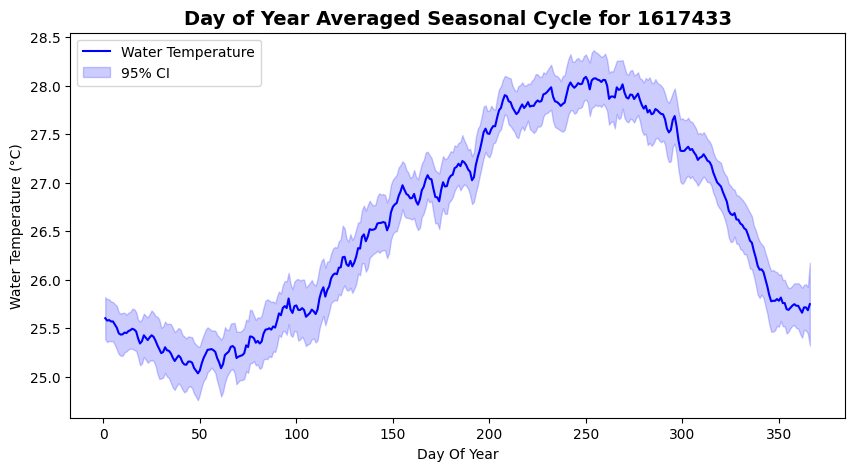

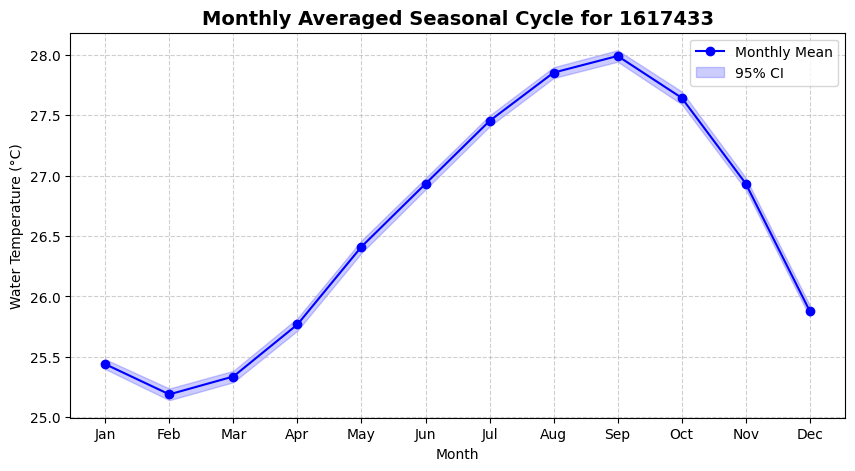

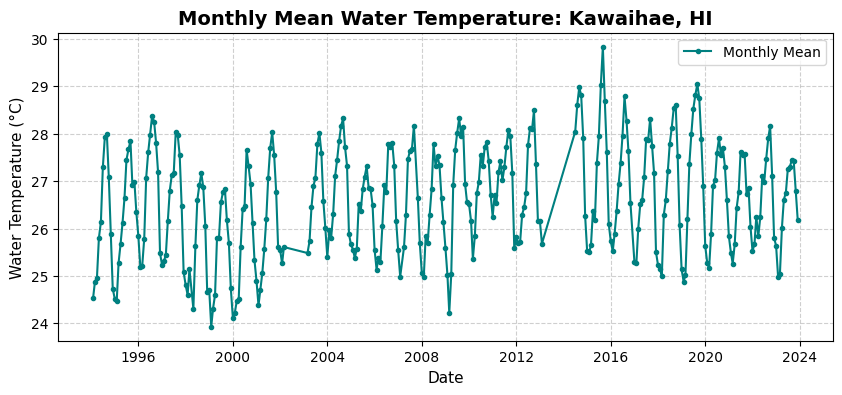

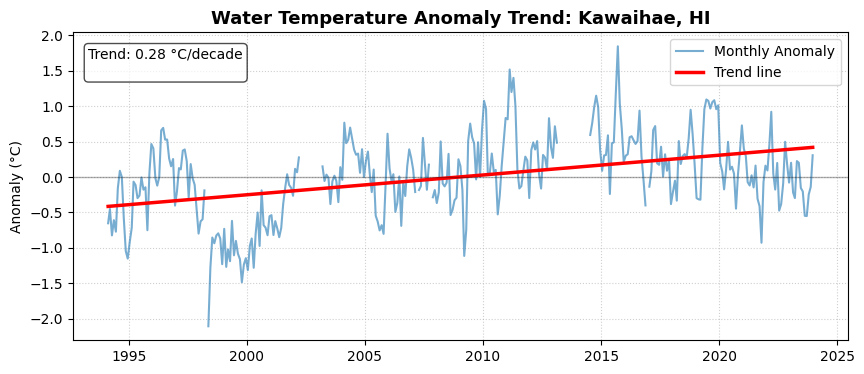


Analysis complete. Results saved to master_trend_analysis_results.csv


In [12]:
# @title Plot and save the graphics

# --- Execution ---
daily_df = pd.read_csv('Metadata and Results/MASTER_daily_clean_water_temp.csv')
monthly_df = pd.read_csv('Metadata and Results/MASTER_monthly_mean_water_temp.csv')

if station_choice == 'single':
    stations_to_process = stationsClim[stationsClim['station_id'].astype(str) == str(station_selection)]
else:
    stations_to_process = stationsClim

results_list = []

for i in stations_to_process.index:
    sid = str(stations_to_process.loc[i, 'station_id'])
    sname = str(stations_to_process.loc[i, 'station_name'])

    print(f"\n" + "="*60)
    print(f"PROCESSING STATION: {sname} ({sid})")
    print("="*60)

    # 1. DOY Seasonal Plot (Line)
    try:
        seasonal_calc_and_plot(daily_df, sid)
    except Exception as e:
        print(f"DOY Seasonal Plot Error: {e}")

    # 2. Monthly Climatology Plot (Line)
    try:
        monthly_climatology_plot(daily_df, sid)
    except Exception as e:
        print(f"Monthly Climatology Plot Error: {e}")

    # 3. Time Series Plot
    try:
        plot_monthly_timeseries(monthly_df, sid, sname)
    except Exception as e:
        print(f"Monthly Timeseries Plot Error: {e}")
    # 4. Trend Analysis
    try:
        stats = notebook_trend_analysis(monthly_df, sid, sname)
        if stats is not None:
            stats['ID'] = sid
            stats['Name'] = sname
            results_list.append(stats)
    except Exception as e:
        print(f"Trend Analysis Error: {e}")

# Save the final results
if results_list:
    pd.DataFrame(results_list).to_csv("master_trend_analysis_results.csv", index=False)
    print(f"\nAnalysis complete. Results saved to master_trend_analysis_results.csv")

## **Conclusions**

### Thank you for taking the time to walk through this Coastal Temperature Seasonality and Trend Viewer Notebook
### This notebook is associated with the Seasonality and Trends in Coastal Water Temperatures from NOAA Water Level Monitoring Stations along the US Coasts publication and replicates some of the station-specific analysis and graphics available in the publication along with the QA/QCed daily and monthly water temperature data and metadata.

